<a href="https://colab.research.google.com/github/siddhamapple/LLM/blob/main/Building_LLM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing necessary functions and libs

In [ ]:
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.4 MB/s eta 0:00:00


In [ ]:
import re
import torch
import tiktoken
import torch.nn as nn
import matplotlib.pyplot as plt


from torch.utils.data import Dataset, DataLoader
from matplotlib.ticker import MaxNLocator

In [ ]:
class GPTDatasetV1(nn.Module):
  def __init__(self,txt,tokenizer,max_length,stride):
    self.input_ids = []
    self.output_ids = []

    token_ids = tokenizer.encode(txt)

    for i in range(0,len(token_ids) - max_length, stride):
        input_chunk = token_ids[i:i+max_length]
        output_chunk = token_ids[i+1:i+max_length+1]
        self.input_ids.append(torch.tensor(input_chunk))
        self.output_ids.append(torch.tensor(output_chunk))

  def __len__(self):
      return len(self.input_ids)

  def __getitem__(self,idx):
      return self.input_ids[idx], self.output_ids[idx]

In [ ]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)


        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)


        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)


        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut


        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):

    for _ in range(max_new_tokens):

        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}


torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

# Training and plotting

In [ ]:
def text_to_token_ids(text,tokenizer):
  encoded = tokenizer.encode(text,allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids,tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context,tokenizer),
    max_new_tokens = 10,
    context_size = GPT_CONFIG_124M["context_length"]
)

print("output: ", token_ids_to_text(token_ids, tokenizer))


output:  Every effort moves you rentingetic wasnم refres RexMeCHicular stren


## importing text file

In [ ]:
!pip install --upgrade --no-cache-dir gdown
!gdown --id 18ZkgVI4tI52qphPcMnlbdblzlZJsJ5Qx -O data.txt

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=18ZkgVI4tI52qphPcMnlbdblzlZJsJ5Qx
To: /content/data.txt
100% 1.83M/1.83M [00:00<00:00, 215MB/s]


In [ ]:
file_path = "data.txt"
with open(file_path, "r" , encoding = "utf-8") as file:
  text_data = file.read()

In [ ]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print(total_characters)
print(total_tokens)

1762015
480067


In [ ]:
train_ratio = 0.8
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


In [ ]:
train_loader = create_dataloader_v1(
    train_data,
    batch_size = 16,
    max_length = GPT_CONFIG_124M['context_length'],
    stride = GPT_CONFIG_124M['context_length'],
    drop_last = True,
    shuffle = True,
    num_workers = 0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size = 16,
    max_length = GPT_CONFIG_124M['context_length'],
    stride = GPT_CONFIG_124M['context_length'],
    drop_last = False,
    shuffle = False,
    num_workers = 0
)

In [ ]:

print("Train loader: ")
for x,y in train_loader:
  print(x.shape,y.shape)

print("Val loader: ")
for x,y in val_loader:
  print(x.shape,y.shape)



Train loader: 
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 2

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(
      logits.flatten(0,1), target_batch.flatten()
  )
  return loss

In [ ]:
# function to compute training and val loss

def calc_loss_loader(data_loader, model, device, num_batches = None):
  total_loss = 0.
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))

  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(
          input_batch,target_batch,model,device
      )
      total_loss += loss.item()
    else:
      break

  return total_loss / num_batches


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
 train_loss = calc_loss_loader(train_loader, model, device)
 val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.981223789014315
Validation loss: 10.977780798207158


In [ ]:
# function for pretraining LLMs

def train_model_simple(model, train_loader, val_loader, optimizer, device,
                      num_epochs, eval_freq, eval_iter, start_context, tokenizer):
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen, global_step = 0, -1
  for epoch in range(num_epochs):
    model.train()

    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()

      loss = calc_loss_batch(
          input_batch, target_batch, model, device
      )

      loss.backward()  # calculatesthe loss gradient
      optimizer.step()  # upodates the model weights using loss gradients
      tokens_seen += input_batch.numel()
      global_step += 1

      if global_step % eval_freq == 0:  # optional evaluation step
        train_loss, eval_loss = evaluate_model(
            model, train_loader, val_loader, device, eval_iter
        )
        train_losses.append(train_loss)
        val_losses.append(eval_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Ep {epoch+1} (Step {global_step:06d}): "
              f"Train loss {train_loss:.3f}, "
              f"Val loss {eval_loss:.3f}"
              )
    generate_and_print_sample(model, tokenizer, device, start_context)  # prints sample text aafter each epoch

  return train_losses, val_losses, track_tokens_seen


In [ ]:
# defining evaluate_model

# this corresponds to step 7 in the figure where we print the lossees to avaluate the performance of training the model

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval() # Dropout is disable during the evaluation process for stable reslts
  with torch.no_grad():
    train_loss = calc_loss_loader( # disables gradient tracking because we dont need it in evaluation
        train_loader, model, device, num_batches = eval_iter
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=eval_iter
    )

  model.train()
  return train_loss, val_loss

In [ ]:

# generate_and_print_sample function takes a text snippet and converts it into token ids and feed it to model to generate a text

def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    token_ids = generate_text_simple(
        model = model,
        idx = encoded,
        max_new_tokens = 50, context_size = context_size
    )

  decoded_text = token_ids_to_text(token_ids, tokenizer)
  print(decoded_text.replace("\n", " "))
  model.train()

In [ ]:
# trainng the GPTModel for 15 epochs

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), lr = 0.0004, weight_decay = 0.1
)
num_epochs = 15
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs = num_epochs, eval_freq = 5, eval_iter = 5,
    start_context = "Every effort moves you", tokenizer = tokenizer
)

Ep 1 (Step 000000): Train loss 9.426, Val loss 9.534
Ep 1 (Step 000005): Train loss 7.708, Val loss 7.882
Ep 1 (Step 000010): Train loss 6.439, Val loss 6.927
Ep 1 (Step 000015): Train loss 6.289, Val loss 6.583
Ep 1 (Step 000020): Train loss 6.350, Val loss 6.516
Ep 1 (Step 000025): Train loss 5.954, Val loss 6.415
Ep 1 (Step 000030): Train loss 6.019, Val loss 6.284
Ep 1 (Step 000035): Train loss 5.863, Val loss 6.211
Ep 1 (Step 000040): Train loss 5.742, Val loss 6.112
Ep 1 (Step 000045): Train loss 5.618, Val loss 6.046
Ep 1 (Step 000050): Train loss 5.685, Val loss 6.003
Ep 1 (Step 000055): Train loss 5.404, Val loss 5.941
Ep 1 (Step 000060): Train loss 5.436, Val loss 5.891
Ep 1 (Step 000065): Train loss 5.324, Val loss 5.855
Ep 1 (Step 000070): Train loss 5.320, Val loss 5.777
Ep 1 (Step 000075): Train loss 5.182, Val loss 5.755
Ep 1 (Step 000080): Train loss 5.208, Val loss 5.716
Ep 1 (Step 000085): Train loss 5.252, Val loss 5.659
Ep 1 (Step 000090): Train loss 5.294, Val loss

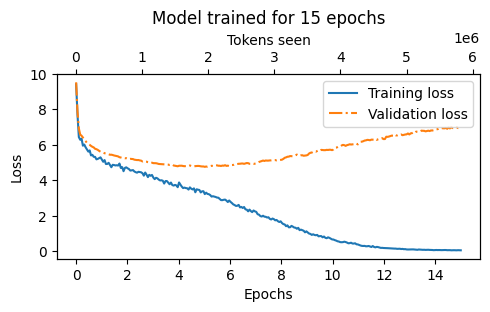

In [ ]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
 fig, ax1 = plt.subplots(figsize=(5, 3))
 ax1.plot(epochs_seen, train_losses, label="Training loss")
 ax1.plot(
 epochs_seen, val_losses, linestyle="-.", label="Validation loss"
 )
 ax1.set_xlabel("Epochs")
 ax1.set_ylabel("Loss")
 ax1.legend(loc="upper right")
 ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
 ax2 = ax1.twiny()
 ax2.plot(tokens_seen, train_losses, alpha=0)
 ax2.set_xlabel("Tokens seen")
 fig.tight_layout()
 plt.title(f"Model trained for 15 epochs")
 plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


In [ ]:
import torch
import gc

# Clear cache
torch.cuda.empty_cache()

# Run garbage collection
gc.collect()

# If you use TPU instead of GPU, reset the session like this:
# from google.colab import runtime
# runtime.unassign()

print("GPU memory cleared.")

GPU memory cleared.


In [ ]:
# trainng the GPTModel for 12 epochs

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), lr = 0.0004, weight_decay = 0.1
)
num_epochs = 12
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs = num_epochs, eval_freq = 5, eval_iter = 5,
    start_context = "Every effort moves you", tokenizer = tokenizer
)

Ep 1 (Step 000000): Train loss 9.426, Val loss 9.534
Ep 1 (Step 000005): Train loss 7.708, Val loss 7.882
Ep 1 (Step 000010): Train loss 6.439, Val loss 6.927
Ep 1 (Step 000015): Train loss 6.289, Val loss 6.583
Ep 1 (Step 000020): Train loss 6.350, Val loss 6.516
Ep 1 (Step 000025): Train loss 5.954, Val loss 6.415
Ep 1 (Step 000030): Train loss 6.019, Val loss 6.284
Ep 1 (Step 000035): Train loss 5.863, Val loss 6.211
Ep 1 (Step 000040): Train loss 5.742, Val loss 6.112
Ep 1 (Step 000045): Train loss 5.618, Val loss 6.046
Ep 1 (Step 000050): Train loss 5.685, Val loss 6.003
Ep 1 (Step 000055): Train loss 5.404, Val loss 5.941
Ep 1 (Step 000060): Train loss 5.436, Val loss 5.891
Ep 1 (Step 000065): Train loss 5.324, Val loss 5.855
Ep 1 (Step 000070): Train loss 5.320, Val loss 5.777
Ep 1 (Step 000075): Train loss 5.182, Val loss 5.755
Ep 1 (Step 000080): Train loss 5.208, Val loss 5.716
Ep 1 (Step 000085): Train loss 5.252, Val loss 5.659
Ep 1 (Step 000090): Train loss 5.294, Val loss

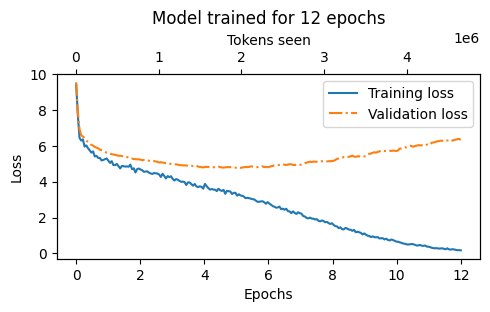

In [ ]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
 fig, ax1 = plt.subplots(figsize=(5, 3))
 ax1.plot(epochs_seen, train_losses, label="Training loss")
 ax1.plot(
 epochs_seen, val_losses, linestyle="-.", label="Validation loss"
 )
 ax1.set_xlabel("Epochs")
 ax1.set_ylabel("Loss")
 ax1.legend(loc="upper right")
 ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
 ax2 = ax1.twiny()
 ax2.plot(tokens_seen, train_losses, alpha=0)
 ax2.set_xlabel("Tokens seen")
 fig.tight_layout()
 plt.title(f"Model trained for 12 epochs")
 plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


In [ ]:
import torch
import gc

# Clear cache
torch.cuda.empty_cache()

# Run garbage collection
gc.collect()

# If you use TPU instead of GPU, reset the session like this:
# from google.colab import runtime
# runtime.unassign()

print("GPU memory cleared.")

GPU memory cleared.


In [ ]:
# trainng the GPTModel for 10 epochs

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), lr = 0.0004, weight_decay = 0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs = num_epochs, eval_freq = 5, eval_iter = 5,
    start_context = "Every effort moves you", tokenizer = tokenizer
)

Ep 1 (Step 000000): Train loss 9.426, Val loss 9.534
Ep 1 (Step 000005): Train loss 7.708, Val loss 7.882
Ep 1 (Step 000010): Train loss 6.439, Val loss 6.927
Ep 1 (Step 000015): Train loss 6.289, Val loss 6.583
Ep 1 (Step 000020): Train loss 6.350, Val loss 6.516
Ep 1 (Step 000025): Train loss 5.954, Val loss 6.415
Ep 1 (Step 000030): Train loss 6.019, Val loss 6.284
Ep 1 (Step 000035): Train loss 5.863, Val loss 6.211
Ep 1 (Step 000040): Train loss 5.742, Val loss 6.112
Ep 1 (Step 000045): Train loss 5.618, Val loss 6.046
Ep 1 (Step 000050): Train loss 5.685, Val loss 6.003
Ep 1 (Step 000055): Train loss 5.404, Val loss 5.941
Ep 1 (Step 000060): Train loss 5.436, Val loss 5.891
Ep 1 (Step 000065): Train loss 5.324, Val loss 5.855
Ep 1 (Step 000070): Train loss 5.320, Val loss 5.777
Ep 1 (Step 000075): Train loss 5.182, Val loss 5.755
Ep 1 (Step 000080): Train loss 5.208, Val loss 5.716
Ep 1 (Step 000085): Train loss 5.252, Val loss 5.659
Ep 1 (Step 000090): Train loss 5.294, Val loss

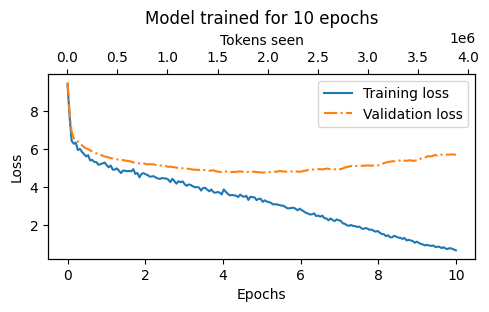

In [ ]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
 fig, ax1 = plt.subplots(figsize=(5, 3))
 ax1.plot(epochs_seen, train_losses, label="Training loss")
 ax1.plot(
 epochs_seen, val_losses, linestyle="-.", label="Validation loss"
 )
 ax1.set_xlabel("Epochs")
 ax1.set_ylabel("Loss")
 ax1.legend(loc="upper right")
 ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
 ax2 = ax1.twiny()
 ax2.plot(tokens_seen, train_losses, alpha=0)
 ax2.set_xlabel("Tokens seen")
 fig.tight_layout()
 plt.title(f"Model trained for 10 epochs")
 plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


In [ ]:
import torch
import gc

# Clear cache
torch.cuda.empty_cache()

# Run garbage collection
gc.collect()

# If you use TPU instead of GPU, reset the session like this:
# from google.colab import runtime
# runtime.unassign()

print("GPU memory cleared.")

GPU memory cleared.


In [ ]:
# trainng the GPTModel for 7 epochs

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), lr = 0.0004, weight_decay = 0.1
)
num_epochs = 7
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs = num_epochs, eval_freq = 5, eval_iter = 5,
    start_context = "Every effort moves you", tokenizer = tokenizer
)


Ep 1 (Step 000000): Train loss 9.426, Val loss 9.534
Ep 1 (Step 000005): Train loss 7.708, Val loss 7.882
Ep 1 (Step 000010): Train loss 6.439, Val loss 6.927
Ep 1 (Step 000015): Train loss 6.289, Val loss 6.583
Ep 1 (Step 000020): Train loss 6.350, Val loss 6.516
Ep 1 (Step 000025): Train loss 5.954, Val loss 6.415
Ep 1 (Step 000030): Train loss 6.019, Val loss 6.284
Ep 1 (Step 000035): Train loss 5.863, Val loss 6.211
Ep 1 (Step 000040): Train loss 5.742, Val loss 6.112
Ep 1 (Step 000045): Train loss 5.618, Val loss 6.046
Ep 1 (Step 000050): Train loss 5.685, Val loss 6.003
Ep 1 (Step 000055): Train loss 5.404, Val loss 5.941
Ep 1 (Step 000060): Train loss 5.436, Val loss 5.891
Ep 1 (Step 000065): Train loss 5.324, Val loss 5.855
Ep 1 (Step 000070): Train loss 5.320, Val loss 5.777
Ep 1 (Step 000075): Train loss 5.182, Val loss 5.755
Ep 1 (Step 000080): Train loss 5.208, Val loss 5.716
Ep 1 (Step 000085): Train loss 5.252, Val loss 5.659
Ep 1 (Step 000090): Train loss 5.294, Val loss

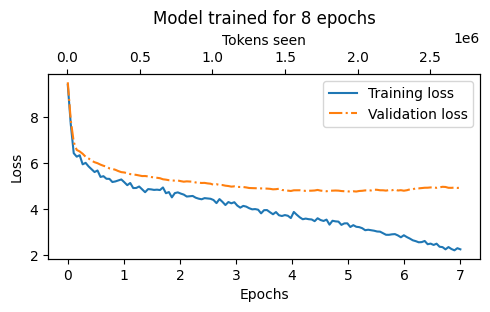

In [ ]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
 fig, ax1 = plt.subplots(figsize=(5, 3))
 ax1.plot(epochs_seen, train_losses, label="Training loss")
 ax1.plot(
 epochs_seen, val_losses, linestyle="-.", label="Validation loss"
 )
 ax1.set_xlabel("Epochs")
 ax1.set_ylabel("Loss")
 ax1.legend(loc="upper right")
 ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
 ax2 = ax1.twiny()
 ax2.plot(tokens_seen, train_losses, alpha=0)
 ax2.set_xlabel("Tokens seen")
 fig.tight_layout()
 plt.title(f"Model trained for 8 epochs")
 plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


In [ ]:
import torch
import gc

# Clear cache
torch.cuda.empty_cache()

# Run garbage collection
gc.collect()

# If you use TPU instead of GPU, reset the session like this:
# from google.colab import runtime
# runtime.unassign()

print("GPU memory cleared.")

GPU memory cleared.


In [ ]:
# trainng the GPTModel for 8 epochs

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), lr = 0.0004, weight_decay = 0.1
)
num_epochs = 8
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs = num_epochs, eval_freq = 5, eval_iter = 5,
    start_context = "Every effort moves you", tokenizer = tokenizer
)


Ep 1 (Step 000000): Train loss 9.426, Val loss 9.534
Ep 1 (Step 000005): Train loss 7.708, Val loss 7.882
Ep 1 (Step 000010): Train loss 6.439, Val loss 6.927
Ep 1 (Step 000015): Train loss 6.289, Val loss 6.583
Ep 1 (Step 000020): Train loss 6.350, Val loss 6.516
Ep 1 (Step 000025): Train loss 5.954, Val loss 6.415
Ep 1 (Step 000030): Train loss 6.019, Val loss 6.284
Ep 1 (Step 000035): Train loss 5.863, Val loss 6.211
Ep 1 (Step 000040): Train loss 5.742, Val loss 6.112
Ep 1 (Step 000045): Train loss 5.618, Val loss 6.046
Ep 1 (Step 000050): Train loss 5.685, Val loss 6.003
Ep 1 (Step 000055): Train loss 5.404, Val loss 5.941
Ep 1 (Step 000060): Train loss 5.436, Val loss 5.891
Ep 1 (Step 000065): Train loss 5.324, Val loss 5.855
Ep 1 (Step 000070): Train loss 5.320, Val loss 5.777
Ep 1 (Step 000075): Train loss 5.182, Val loss 5.755
Ep 1 (Step 000080): Train loss 5.208, Val loss 5.716
Ep 1 (Step 000085): Train loss 5.252, Val loss 5.659
Ep 1 (Step 000090): Train loss 5.294, Val loss

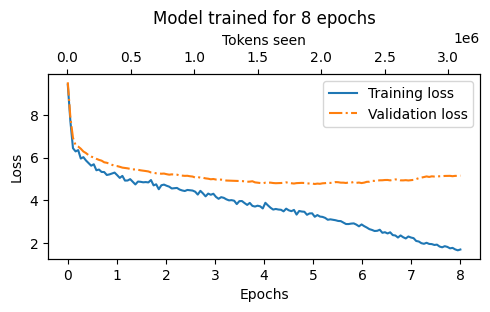

In [ ]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
 fig, ax1 = plt.subplots(figsize=(5, 3))
 ax1.plot(epochs_seen, train_losses, label="Training loss")
 ax1.plot(
 epochs_seen, val_losses, linestyle="-.", label="Validation loss"
 )
 ax1.set_xlabel("Epochs")
 ax1.set_ylabel("Loss")
 ax1.legend(loc="upper right")
 ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
 ax2 = ax1.twiny()
 ax2.plot(tokens_seen, train_losses, alpha=0)
 ax2.set_xlabel("Tokens seen")
 fig.tight_layout()
 plt.title(f"Model trained for 8 epochs")
 plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


In [ ]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [ ]:
# we are now combining temperature scaling and top k sampling to modify the function

def generate(model, idx, max_new_tokens, context_size, temperature = 0.0, top_k = None, eos_id = None):
  for _ in range(max_new_tokens):
    idx_cond = idx[:,-context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]
    if top_k is not None:
      top_logits,_ = torch.topk(logits,top_k)
      min_value = top_logits[:, -1]
      logits = torch.where(
          logits < min_value,
          torch.tensor(float('-inf')).to(logits.device),
          logits
      )
    if temperature > 0.0:
      logits = logits / temperature
      probs = torch.softmax(logits, dim = -1)
      idx_next = torch.multinomial(probs, num_samples = 1)
    else:
      idx_next = torch.argmax(logits, dim = -1, keepdim = True)
    if idx_next == eos_id:
      break
    idx = torch.cat((idx,idx_next), dim = -1)
  return idx

In [ ]:
torch.manual_seed(123)
token_ids = generate(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens = 15,
    context_size = GPT_CONFIG_124M['context_length'],
    top_k = 25,
    temperature = 1.4
)
print("output: ", token_ids_to_text(token_ids, tokenizer))


output:  Every effort moves you have made a pleasant transaction to a little girl, of
her if not


In [ ]:
torch.save({
    "epochs": num_epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
  },
    "/content/drive/MyDrive/model_and_optimizer.pth"
)

# Trained model

In [ ]:
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.4 MB/s eta 0:00:00


In [ ]:
import torch
import tiktoken
import torch.nn as nn

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [ ]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

## Importing model from cloud

In [ ]:
!pip install --upgrade --no-cache-dir gdown
!gdown --id 1EzBx_wkEJoQWMLfjTZqzq_uK4b4cDWMF -O model_and_optimizer.pth

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1EzBx_wkEJoQWMLfjTZqzq_uK4b4cDWMF
From (redirected): https://drive.google.com/uc?id=1EzBx_wkEJoQWMLfjTZqzq_uK4b4cDWMF&confirm=t&uuid=72e73677-dfd1-4abf-8f23-c7ebcc587d65
To: /content/model_and_optimizer.pth
100% 1.95G/1.95G [00:27<00:00, 70.4MB/s]


In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [ ]:

model = GPTModel(GPT_CONFIG_124M)

checkpoint = torch.load("model_and_optimizer.pth", map_location="cuda", weights_only=False)  # Change to "cpu" if needed
model.load_state_dict(checkpoint["model_state_dict"])


model.eval()

print(" Model successfully loaded!")

 Model successfully loaded!


In [ ]:
def text_to_token_ids(text,tokenizer):
  encoded = tokenizer.encode(text,allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids,tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context,tokenizer),
    max_new_tokens = 10,
    context_size = GPT_CONFIG_124M["context_length"]
)

print("output: ", token_ids_to_text(token_ids, tokenizer))

output:  Every effort moves you have done it?”

“


In [ ]:
def generate(model, idx, max_new_tokens, context_size, temperature = 0.0, top_k = None, eos_id = None):
  for _ in range(max_new_tokens):
    idx_cond = idx[:,-context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]
    if top_k is not None:
      top_logits,_ = torch.topk(logits,top_k)
      min_value = top_logits[:, -1]
      logits = torch.where(
          logits < min_value,
          torch.tensor(float('-inf')).to(logits.device),
          logits
      )
    if temperature > 0.0:
      logits = logits / temperature
      probs = torch.softmax(logits, dim = -1)
      idx_next = torch.multinomial(probs, num_samples = 1)
    else:
      idx_next = torch.argmax(logits, dim = -1, keepdim = True)
    if idx_next == eos_id:
      break
    idx = torch.cat((idx,idx_next), dim = -1)
  return idx

In [ ]:
token_ids = generate(
    model = model,
    idx = text_to_token_ids("Hello, I am", tokenizer),
    max_new_tokens = 15,
    context_size = GPT_CONFIG_124M['context_length'],
    top_k = 25,
    temperature = 1.4
)
print("output: ", token_ids_to_text(token_ids, tokenizer))

output:  Hello, I am sure, so should have
thought of it, without feeling
nothing in


**Conclusion** of this project:
In this project, I successfully implemented a simplified GPT-2 style language model from scratch with random initialization and pre-trained  it using-

1. Tokenization and vocabulary construction

2. Custom dataset preparation using sliding window technique

3. Training loop using PyTorch and validation split

4. Loss tracking and visualization

5. Text generation from a given context using a trained model

The end-to-end workflow—from data preprocessing to model saving and deployment—was built into a single, self-contained Colab notebook, ensuring reproducibility and portability. The model can be directly loaded from the cloud and used for inference without re-training.